#### Name: 

### <font color='purple'> Comments </font> 

<font color='purple'> no name: -2 points </font> 


# PHYS 230 Lab Assignment 14

### Monday, March 30, 2026: Chapter 8.1
- First-order differential equations 

In [26]:
# import statements here
import numpy as np
import math
import matplotlib.pyplot as plt

### The problem:

Today we will solve a first-order ordinary differential equation for the velocity of a falling ball with air resistance (assuming linear drag). This equation, assuming vertical motion only and downwards as the positive y-direction, is given as: 

$$\frac{dv}{dt}= g -\frac{b}{m}v $$

The exact solution to this differential equation is: 

$$ v(t) = v_0 e^{-\frac{b}{m}t} + v_{\text{ter}} \left( 1 -  e^{-\frac{b}{m}t} \right) $$


where $v_0$ is the initial velocity and $v_{\text{ter}} = \frac{mg}{b}$ is the terminal velocity. For this problem, we will assume that our 1.0 kg ball is initially at rest, so $v_0 = 0$ at $t=0$, the graviational acceleration $g = 9.8 \text{ m/s}^2$, and the drag coefficient $b = 0.1 \frac{\text{N}}{\text{m/s}}$. 

*don't forget comments in your code cells*

### Part 1: Exact Solution

Calculate the exact solution of $v(t)$ for an array of times. Do this in the following steps: 

#### Step 1: 

Write a function `v(t,b,m,v0)` that takes in an array of times (from $t=0$ to $t=100$ by 2's) and constants $b,m,v_0$ and returns an array of velocities using the equation above. Think about any constants might need to be included inside the function. 

In [27]:
#define solution to differential equation
def v(t,b,m,v0):
    v_ter = m*g/b
    return (v0*(np.exp(-b*t/m)))+(v_ter*(1-(np.exp(-b*t/m))))

#### Step 2: 

Define the array of times $t$, or whatever variable you want to use, and your necessary constants, and calculate the array of velocities using your function. 

In [35]:
#define constants
m = 1.0 #kg
v0 = 0
g = 9.8 #m/s/s
b = 0.1 #N/(m/s)
t_0 = 0 #s
t_f = 100 #s
h = 2 #s

#array of time to use to make velocities
t_arr = np.arange(t_0,t_f+h,h)

#actual results array
result_ac = v(t_arr,b,m,v0)
print(result_ac)

[ 0.         17.7643862  32.30863549 44.21645966 53.96576152 61.94781477
 68.48296723 73.83349753 78.21414124 81.80070895 84.73714224 87.14129048
 89.10964058 90.72118933 92.04061386 93.1208673  94.00530401 94.72941954
 95.3222752  95.80766436 96.20506739 96.53043347 96.79682069 97.0149201
 97.19348479 97.33968119 97.45937669 97.55737507 97.63760936 97.70329963
 97.75708229 97.8011158  97.83716739 97.86668393 97.89085004 97.91063557
 97.92683459 97.94009723 97.95095576 97.95984597 97.96712466 97.97308395
 97.977963   97.98195763 97.98522816 97.98790584 97.99009814 97.99189304
 97.99336258 97.99456574 97.99555081]


#### Step 3: 
Make a plot of the results. 

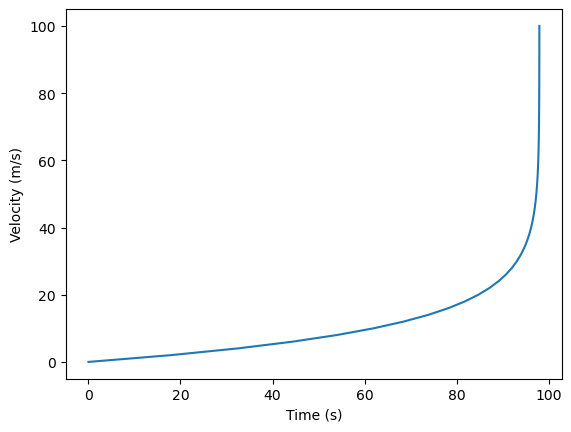

In [36]:
#plot actual results
plt.plot(result_ac, t_arr)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.show()

### <font color='purple'> Comments </font> 

<font color='purple'> you have plotted this backwards. `plt.plot()` is plotted xaxis, yaxis - you have put your velocity results on the xaxis! 

make this points! want to see the actual data points. </font> 


### Part 2: Euler Method

Calculate the solution for the same array of times using the Euler method instead. 

#### Step 1: 

Write two functions: `f(v)` that calculate the result of the differential equation for vertical, linear projectile motion, and `euler(t,h,v0,f)` that takes in an array $t$ of times in the same range as part 1 and using a defined $h$ value,initial conditions, and the differential equation returns an *array*. 

In [37]:
#define differential equation
def f(v):
    return g - (b*v/m)

#runs euler method
def euler(t,h,v0,f):
    v_arr = np.zeros(len(t)) #creates array of zeros
    for i in range(len(t)): #fills array
        v_arr[i] = v0
        v0 += h*f(v0)
    return v_arr #returns filled array

### <font color='purple'> Comments </font> 

<font color='purple'> great! </font> 


#### Step 2

Calculate the array of velocities usig your `euler` function and make a plot of the results with the exact calculation on the **same** graph (put both results on the same graph here).

[ 0.         19.6        35.28       47.824      57.8592     65.88736
 72.309888   77.4479104  81.55832832 84.84666266 87.47733012 89.5818641
 91.26549128 92.61239302 93.68991442 94.55193154 95.24154523 95.79323618
 96.23458895 96.58767116 96.87013693 97.09610954 97.27688763 97.42151011
 97.53720808 97.62976647 97.70381317 97.76305054 97.81044043 97.84835235
 97.87868188 97.9029455  97.9223564  97.93788512 97.9503081  97.96024648
 97.96819718 97.97455775 97.9796462  97.98371696 97.98697357 97.98957885
 97.99166308 97.99333047 97.99466437 97.9957315  97.9965852  97.99726816
 97.99781453 97.99825162 97.9986013 ]


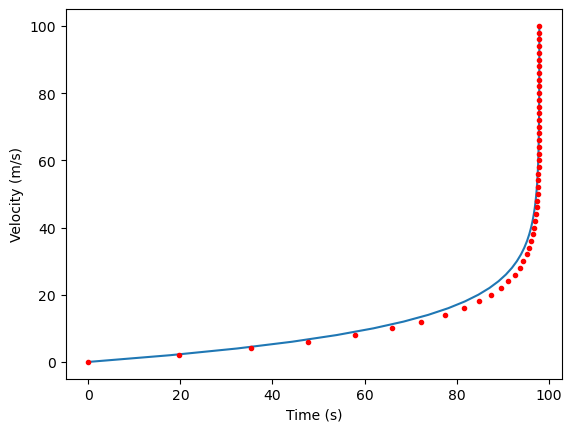

In [38]:
#euler vs. actual results
result_euler = euler(t_arr,h,v0,f)
print(result_euler)

plt.plot(result_ac, t_arr)
plt.plot(result_euler, t_arr, "r.")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.show()

### <font color='purple'> Comments </font> 

<font color='purple'>good just flipped the plotting!  </font> 


### Part 3: Fourth-order Runge-Kutta Method

Calculate the solution for the same array of times using the Runge-Kutta method instead. For this, define a function `RK4(t,h,v0,f)` that takes in an array of times, initial velocity, $h$, initial conditions, and differential equation function. 

Plot this as well as the exact and Euler solutions on the **same** graph as well. 

[ 0.         17.76413333 32.30822143 44.21595116 53.96520641 61.94724666
 68.48240909 73.8329644  78.21364239 81.80024948 84.73672425 87.14091404
 89.10930435 90.72089112 92.04035092 93.12063664 94.00510257 94.72924431
 95.3221233  95.80753308 96.20495425 96.53033621 96.79673727 97.01484869
 97.19342378 97.33962917 97.45933239 97.5573374  97.63757738 97.70327252
 97.75705932 97.80109637 97.83715096 97.86667007 97.89083834 97.91062571
 97.92682629 97.94009024 97.95094989 97.95984104 97.96712052 97.97308047
 97.97796009 97.98195519 97.98522611 97.98790412 97.9900967  97.99189184
 97.99336158 97.9945649  97.99555011]


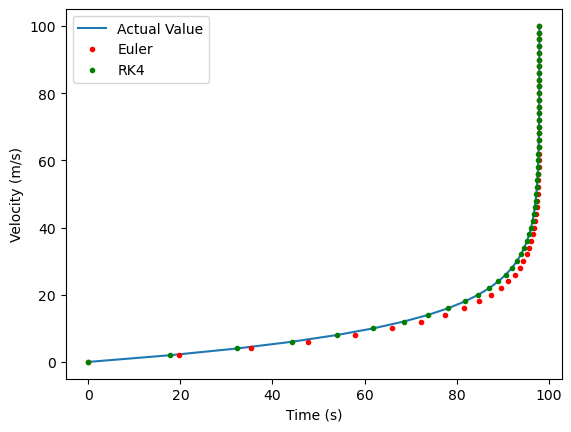

In [43]:
#performs RK4 method
def RK4(t,h,v0,f):
    v_arr = np.zeros(len(t))
    for i in range(len(t_arr)):
        v_arr[i] = v0
        k_1 = h*f(v0)
        k_2 = h*f(v0+0.5*k_1)
        k_3 = h*f(v0+0.5*k_2)
        k_4 = h*f(v0+k_3)
        v0 += (1/6)*(k_1+2*k_2+2*k_3+k_4)
    return v_arr

#plot euler vs. RK4 vs. actual values
result_rk = RK4(t_arr,h,v0,f)
print(result_rk)

plt.plot(result_ac, t_arr, label = "Actual Value")
plt.plot(result_euler, t_arr, "r.", label= "Euler")
plt.plot(result_rk, t_arr, "g.", label= "RK4")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.show()

### <font color='purple'> Comments </font> 

<font color='purple'> excellent besides the backwards plot! </font> 


### Part 4: Markdown comparision

What can you conclude about the results? Do they all agree? (Explain in a markdown cell below - you will need to change it to a markdown cell first)

RK4 is a lot more accurate than Euler asshown above (for the same number of steps). RK4 is difficult to differentiate from the actual values, while Euler definitely has some error.

### Part 5: Adjust

Try using smaller and bigger time steps to see the effect of improving your approximations (Euler and/or Runge-Kutta). Explain your results and process in markdown. 

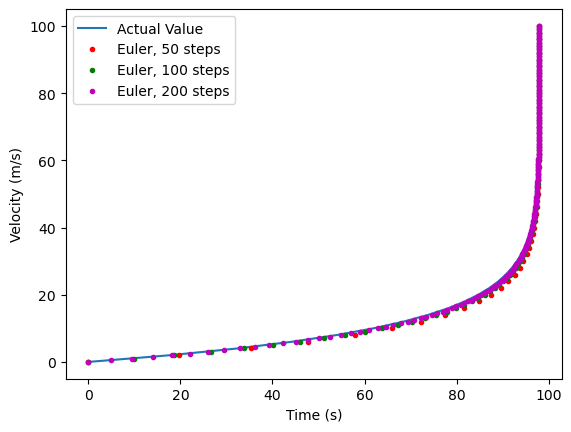

In [53]:
#performs euler again with twice the steps
h2 = h/2
t_arr2 = np.arange(t_0,t_f+h2,h2)
result_euler_2 = euler(t_arr2,h2,v0,f)

#perform euler again with 4 times the steps
h4 = h/4
t_arr4 = np.arange(t_0,t_f+h4,h4)
result_euler_4 = euler(t_arr4,h4,v0,f)

#plots three eulers to compare
plt.plot(result_ac, t_arr, label = "Actual Value")
plt.plot(result_euler, t_arr, "r.", label= "Euler, 50 steps")
plt.plot(result_euler_2, t_arr2, "g.", label= "Euler, 100 steps")
plt.plot(result_euler_4, t_arr4, "m.", label= "Euler, 200 steps")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.show()

#### Explanation Markdown Cell: 

Doubling the number of steps improves the Euler estimate significantly. But even with four times the steps of RK4 (200 vs. 50), Euler still looks less accurate.

### <font color='purple'> Comments </font> 

<font color='purple'> did you try less? says smaller and bigger</font> 
